In [9]:
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Load Data
X_train = pd.read_csv("X_train_clean.csv")
X_test = pd.read_csv("X_test_clean.csv")

y_train = pd.read_csv("y_train.csv").values.ravel()
y_test = pd.read_csv("y_test.csv").values.ravel()

# Baseline Linear SVM
svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', LinearSVC(
        class_weight='balanced',
        random_state=42,
        max_iter=10000
    ))
])

# Train
svm.fit(X_train, y_train)

# Predictions
train_pred = svm.predict(X_train)
test_pred = svm.predict(X_test)

print("="*50)
print("IN-SAMPLE PERFORMANCE")
print("="*50)

print("Accuracy :", accuracy_score(y_train, train_pred))
print("Precision:", precision_score(y_train, train_pred, average='weighted'))
print("Recall   :", recall_score(y_train, train_pred, average='weighted'))
print("F1 Score :", f1_score(y_train, train_pred, average='weighted'))

print("\n"+"="*50)
print("OUT-OF-SAMPLE PERFORMANCE")
print("="*50)

print("Accuracy :", accuracy_score(y_test, test_pred))
print("Precision:", precision_score(y_test, test_pred, average='weighted'))
print("Recall   :", recall_score(y_test, test_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, test_pred, average='weighted'))

print("\nClassification Report")
print(classification_report(y_test, test_pred))

IN-SAMPLE PERFORMANCE
Accuracy : 0.8287448224007948
Precision: 0.8701639290020907
Recall   : 0.8287448224007948
F1 Score : 0.8465133537031286

OUT-OF-SAMPLE PERFORMANCE
Accuracy : 0.426051151580075
Precision: 0.5522508919462179
Recall   : 0.426051151580075
F1 Score : 0.4601415663326409

Classification Report
              precision    recall  f1-score   support

           0       0.13      0.32      0.18      1525
           1       0.00      0.00      0.00      1667
           2       0.00      0.00      0.00      1040
           3       0.00      0.00      0.00      1012
           4       0.61      0.18      0.27      4827
           5       0.20      0.20      0.20      1388
           6       0.19      0.55      0.28      1231
           7       0.75      0.61      0.67     17182

    accuracy                           0.43     29872
   macro avg       0.23      0.23      0.20     29872
weighted avg       0.55      0.43      0.46     29872



In [10]:
from sklearn.model_selection import train_test_split, GridSearchCV

# 80-20 Split
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=42
)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', LinearSVC(
        class_weight='balanced',
        random_state=42,
        max_iter=10000
    ))
])

param_grid = {
    'svm__C': [0.01, 0.1, 1, 10]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=3,
    scoring='f1_weighted',
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_sub, y_train_sub)

print("Best Parameters:")
print(grid_search.best_params_)

print("Best CV Score:")
print(grid_search.best_score_)

best_svm = grid_search.best_estimator_

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best Parameters:
{'svm__C': 10}
Best CV Score:
0.8469891790386145


In [11]:
# In-Sample
train_pred = best_svm.predict(X_train_sub)

print("="*50)
print("IN-SAMPLE PERFORMANCE")
print("="*50)

print("Accuracy :", accuracy_score(y_train_sub, train_pred))
print("Precision:", precision_score(y_train_sub, train_pred, average='weighted'))
print("Recall   :", recall_score(y_train_sub, train_pred, average='weighted'))
print("F1 Score :", f1_score(y_train_sub, train_pred, average='weighted'))

# Validation
val_pred = best_svm.predict(X_val)

print("\n"+"="*50)
print("VALIDATION PERFORMANCE")
print("="*50)

print("Accuracy :", accuracy_score(y_val, val_pred))
print("Precision:", precision_score(y_val, val_pred, average='weighted'))
print("Recall   :", recall_score(y_val, val_pred, average='weighted'))
print("F1 Score :", f1_score(y_val, val_pred, average='weighted'))

# Test
test_pred = best_svm.predict(X_test)

print("\n"+"="*50)
print("OUT-OF-SAMPLE PERFORMANCE")
print("="*50)

print("Accuracy :", accuracy_score(y_test, test_pred))
print("Precision:", precision_score(y_test, test_pred, average='weighted'))
print("Recall   :", recall_score(y_test, test_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, test_pred, average='weighted'))

print("\nClassification Report")
print(classification_report(y_test, test_pred))

IN-SAMPLE PERFORMANCE
Accuracy : 0.8293235543397082
Precision: 0.8705337119640802
Recall   : 0.8293235543397082
F1 Score : 0.8469700903227667

VALIDATION PERFORMANCE
Accuracy : 0.8311291621911923
Precision: 0.8712518838218719
Recall   : 0.8311291621911923
F1 Score : 0.8481253300205897

OUT-OF-SAMPLE PERFORMANCE
Accuracy : 0.4283275307980718
Precision: 0.5538566007479281
Recall   : 0.4283275307980718
F1 Score : 0.46143969337602614

Classification Report
              precision    recall  f1-score   support

           0       0.14      0.31      0.19      1525
           1       0.00      0.00      0.00      1667
           2       0.00      0.00      0.00      1040
           3       0.00      0.00      0.00      1012
           4       0.60      0.17      0.27      4827
           5       0.21      0.22      0.22      1388
           6       0.21      0.62      0.31      1231
           7       0.75      0.61      0.67     17182

    accuracy                           0.43     29872
 

In [12]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Baseline SVM", "Tuned SVM"],
    "Accuracy": [
        accuracy_score(y_test, svm.predict(X_test)),
        accuracy_score(y_test, best_svm.predict(X_test))
    ],
    "Precision": [
        precision_score(y_test, svm.predict(X_test), average='weighted'),
        precision_score(y_test, best_svm.predict(X_test), average='weighted')
    ],
    "Recall": [
        recall_score(y_test, svm.predict(X_test), average='weighted'),
        recall_score(y_test, best_svm.predict(X_test), average='weighted')
    ],
    "F1 Score": [
        f1_score(y_test, svm.predict(X_test), average='weighted'),
        f1_score(y_test, best_svm.predict(X_test), average='weighted')
    ]
})

print(comparison.round(4))

          Model  Accuracy  Precision  Recall  F1 Score
0  Baseline SVM    0.4261     0.5523  0.4261    0.4601
1     Tuned SVM    0.4283     0.5539  0.4283    0.4614


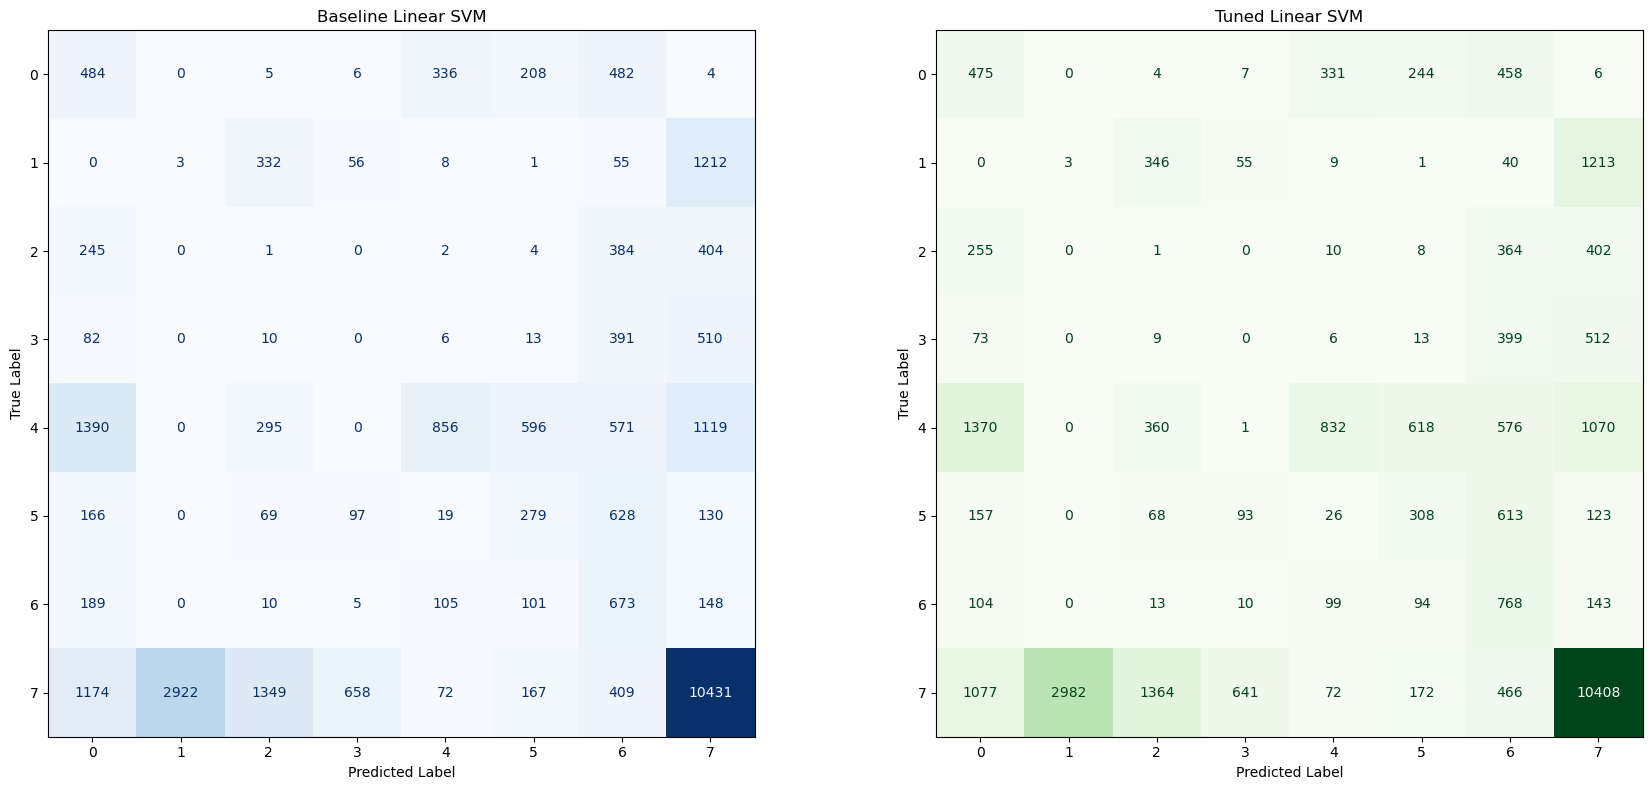

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predictions
baseline_pred = svm.predict(X_test)
tuned_pred = best_svm.predict(X_test)

# Confusion Matrices
cm_baseline = confusion_matrix(y_test, baseline_pred)
cm_tuned = confusion_matrix(y_test, tuned_pred)

# Plot Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Baseline SVM
ConfusionMatrixDisplay(
    confusion_matrix=cm_baseline,
    display_labels=svm.classes_
).plot(
    ax=axes[0],
    cmap="Blues",
    colorbar=False,
    values_format='d'
)

axes[0].set_title("Baseline Linear SVM")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# Tuned SVM
ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=best_svm.classes_
).plot(
    ax=axes[1],
    cmap="Greens",
    colorbar=False,
    values_format='d'
)

axes[1].set_title("Tuned Linear SVM")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()

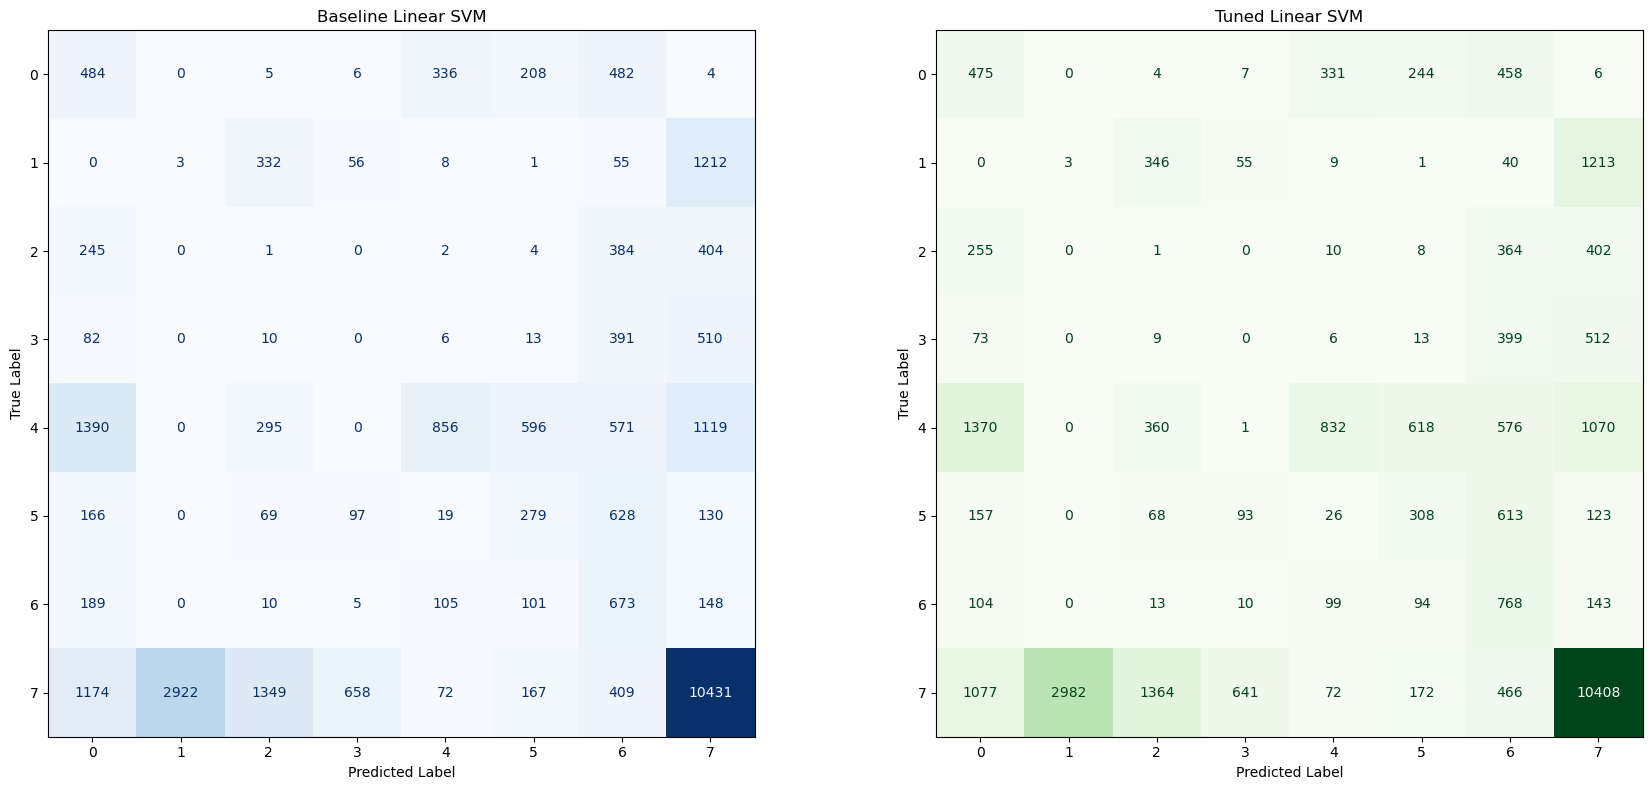

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predictions
baseline_pred = svm.predict(X_test)
tuned_pred = best_svm.predict(X_test)

# Confusion Matrices
cm_baseline = confusion_matrix(y_test, baseline_pred)
cm_tuned = confusion_matrix(y_test, tuned_pred)

# Plot Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Baseline SVM
ConfusionMatrixDisplay(
    confusion_matrix=cm_baseline,
    display_labels=svm.classes_
).plot(
    ax=axes[0],
    cmap="Blues",
    colorbar=False,
    values_format='d'
)

axes[0].set_title("Baseline Linear SVM")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# Tuned SVM
ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=best_svm.classes_
).plot(
    ax=axes[1],
    cmap="Greens",
    colorbar=False,
    values_format='d'
)

axes[1].set_title("Tuned Linear SVM")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()


In [15]:

import pandas as pd
from sklearn.metrics import classification_report

# Predictions
baseline_pred = svm.predict(X_test)
tuned_pred = best_svm.predict(X_test)

# Classification Reports
baseline_report = pd.DataFrame(
    classification_report(
        y_test,
        baseline_pred,
        output_dict=True,
        zero_division=0
    )
).transpose()

tuned_report = pd.DataFrame(
    classification_report(
        y_test,
        tuned_pred,
        output_dict=True,
        zero_division=0
    )
).transpose()

precision_table = pd.DataFrame({
    "Class": baseline_report.index[:-3],
    "Baseline Precision": baseline_report.loc[
        baseline_report.index[:-3], "precision"
    ].values,
    "Tuned Precision": tuned_report.loc[
        tuned_report.index[:-3], "precision"
    ].values
})

precision_table = precision_table.round(4)

print("Precision Comparison")
display(precision_table)

recall_table = pd.DataFrame({
    "Class": baseline_report.index[:-3],
    "Baseline Recall": baseline_report.loc[
        baseline_report.index[:-3], "recall"
    ].values,
    "Tuned Recall": tuned_report.loc[
        tuned_report.index[:-3], "recall"
    ].values
})

recall_table = recall_table.round(4)

print("Recall Comparison")
display(recall_table)

f1_table = pd.DataFrame({
    "Class": baseline_report.index[:-3],
    "Baseline F1-Score": baseline_report.loc[
        baseline_report.index[:-3], "f1-score"
    ].values,
    "Tuned F1-Score": tuned_report.loc[
        tuned_report.index[:-3], "f1-score"
    ].values
})

f1_table = f1_table.round(4)

print("F1-Score Comparison")
display(f1_table)

import numpy as np
from sklearn.metrics import accuracy_score

classes = np.unique(y_test)

accuracy_list = []

for cls in classes:

    y_true_binary = (y_test == cls).astype(int)

    baseline_binary = (baseline_pred == cls).astype(int)
    tuned_binary = (tuned_pred == cls).astype(int)

    accuracy_list.append([
        cls,
        accuracy_score(y_true_binary, baseline_binary),
        accuracy_score(y_true_binary, tuned_binary)
    ])

accuracy_table = pd.DataFrame(
    accuracy_list,
    columns=[
        "Class",
        "Baseline Accuracy",
        "Tuned Accuracy"
    ]
)

accuracy_table = accuracy_table.round(4)

print("Individual Class Accuracy")
display(accuracy_table)

comparison_table = pd.DataFrame({
    "Class": baseline_report.index[:-3],

    "Baseline Precision":
        baseline_report.loc[
            baseline_report.index[:-3],
            "precision"
        ].values,

    "Tuned Precision":
        tuned_report.loc[
            tuned_report.index[:-3],
            "precision"
        ].values,

    "Baseline Recall":
        baseline_report.loc[
            baseline_report.index[:-3],
            "recall"
        ].values,

    "Tuned Recall":
        tuned_report.loc[
            tuned_report.index[:-3],
            "recall"
        ].values,

    "Baseline F1":
        baseline_report.loc[
            baseline_report.index[:-3],
            "f1-score"
        ].values,

    "Tuned F1":
        tuned_report.loc[
            tuned_report.index[:-3],
            "f1-score"
        ].values,

    "Baseline Accuracy":
        accuracy_table["Baseline Accuracy"],

    "Tuned Accuracy":
        accuracy_table["Tuned Accuracy"]
})

comparison_table = comparison_table.round(4)

print("Linear SVM: Baseline vs Tuned")
display(comparison_table)

Precision Comparison


,Class,Baseline Precision,Tuned Precision
0,0,0.1298,0.1353
1,1,0.0010,0.0010
2,2,0.0005,0.0005
3,3,0.0000,0.0000
4,4,0.6097,0.6007
5,5,0.2038,0.2112
6,6,0.1873,0.2085
7,7,0.7473,0.7500


Recall Comparison


,Class,Baseline Recall,Tuned Recall
0,0,0.3174,0.3115
1,1,0.0018,0.0018
2,2,0.0010,0.0010
3,3,0.0000,0.0000
4,4,0.1773,0.1724
5,5,0.2010,0.2219
6,6,0.5467,0.6239
7,7,0.6071,0.6058


F1-Score Comparison


,Class,Baseline F1-Score,Tuned F1-Score
0,0,0.1842,0.1886
1,1,0.0013,0.0013
2,2,0.0006,0.0006
3,3,0.0000,0.0000
4,4,0.2748,0.2679
5,5,0.2024,0.2164
6,6,0.2790,0.3125
7,7,0.6699,0.6702


Individual Class Accuracy


,Class,Baseline Accuracy,Tuned Accuracy
0,0,0.8565,0.8632
1,1,0.8465,0.8445
2,2,0.8959,0.8928
3,3,0.9386,0.9391
4,4,0.8487,0.8478
5,5,0.9264,0.9253
6,6,0.8836,0.8869
7,7,0.6559,0.6571


Linear SVM: Baseline vs Tuned


,Class,Baseline Precision,Tuned Precision,Baseline Recall,Tuned Recall,Baseline F1,Tuned F1,Baseline Accuracy,Tuned Accuracy
0,0,0.1298,0.1353,0.3174,0.3115,0.1842,0.1886,0.8565,0.8632
1,1,0.0010,0.0010,0.0018,0.0018,0.0013,0.0013,0.8465,0.8445
2,2,0.0005,0.0005,0.0010,0.0010,0.0006,0.0006,0.8959,0.8928
3,3,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.9386,0.9391
4,4,0.6097,0.6007,0.1773,0.1724,0.2748,0.2679,0.8487,0.8478
5,5,0.2038,0.2112,0.2010,0.2219,0.2024,0.2164,0.9264,0.9253
6,6,0.1873,0.2085,0.5467,0.6239,0.2790,0.3125,0.8836,0.8869
7,7,0.7473,0.7500,0.6071,0.6058,0.6699,0.6702,0.6559,0.6571


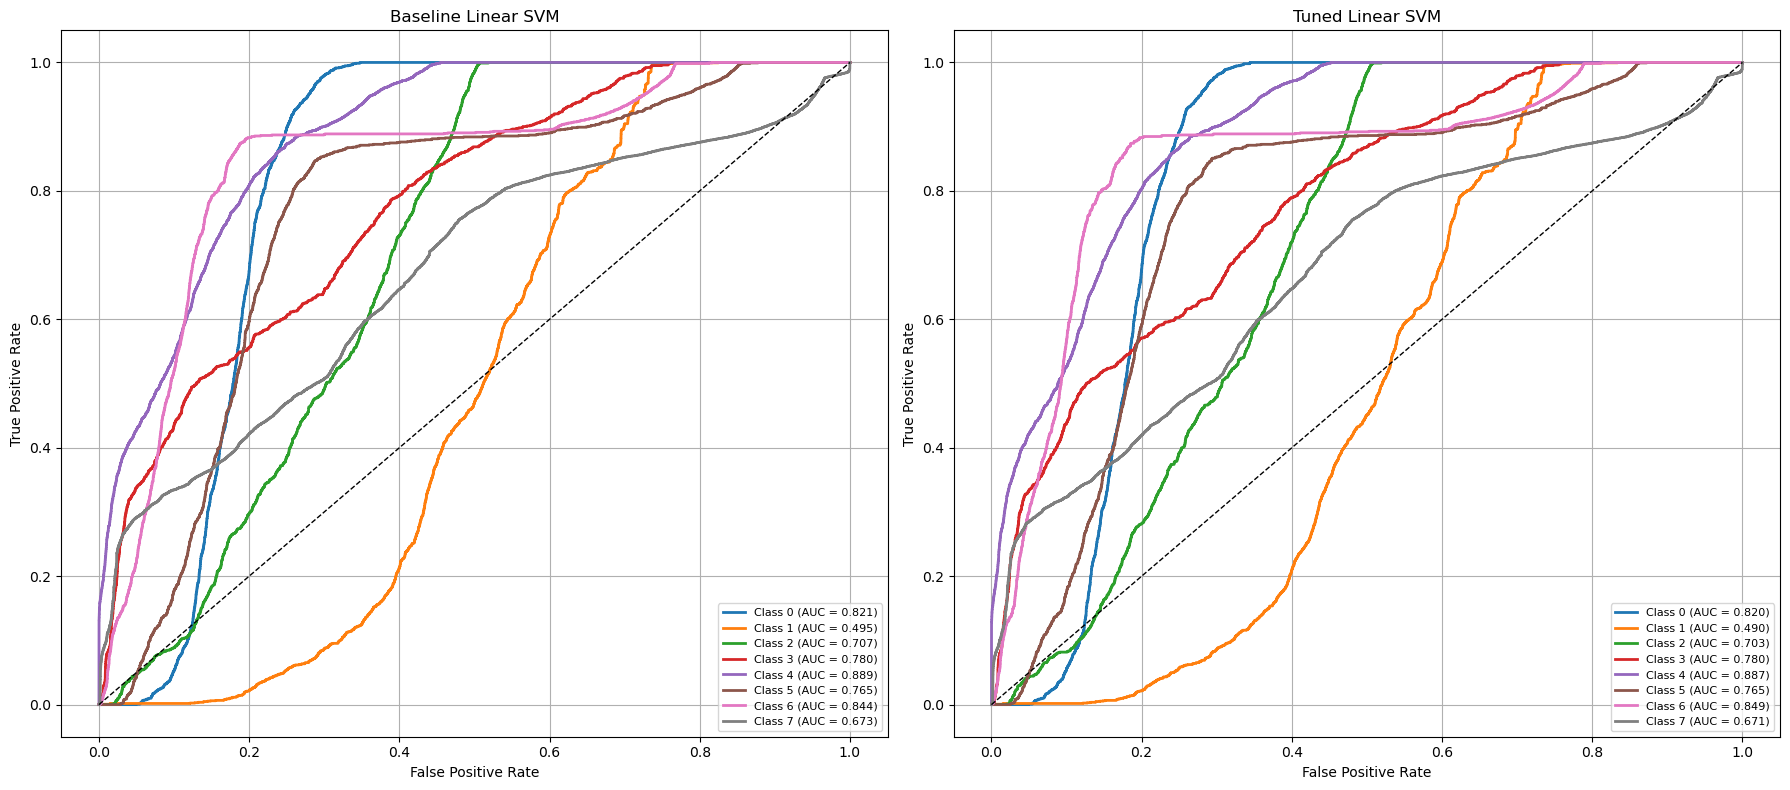

In [19]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Classes
classes = np.unique(y_test)

# Binarize labels
y_test_bin = label_binarize(y_test, classes=classes)

# Decision scores (NOT predict_proba)
baseline_scores = svm.decision_function(X_test)
tuned_scores = best_svm.decision_function(X_test)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --------------------------------------------------
# Baseline Linear SVM
# --------------------------------------------------
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        baseline_scores[:, i]
    )

    roc_auc = auc(fpr, tpr)

    axes[0].plot(
        fpr,
        tpr,
        lw=2,
        label=f"Class {classes[i]} (AUC = {roc_auc:.3f})"
    )

axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_title("Baseline Linear SVM")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right", fontsize=8)
axes[0].grid(True)

# --------------------------------------------------
# Tuned Linear SVM
# --------------------------------------------------
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        tuned_scores[:, i]
    )

    roc_auc = auc(fpr, tpr)

    axes[1].plot(
        fpr,
        tpr,
        lw=2,
        label=f"Class {classes[i]} (AUC = {roc_auc:.3f})"
    )

axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_title("Tuned Linear SVM")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right", fontsize=8)
axes[1].grid(True)

plt.tight_layout()
plt.show()

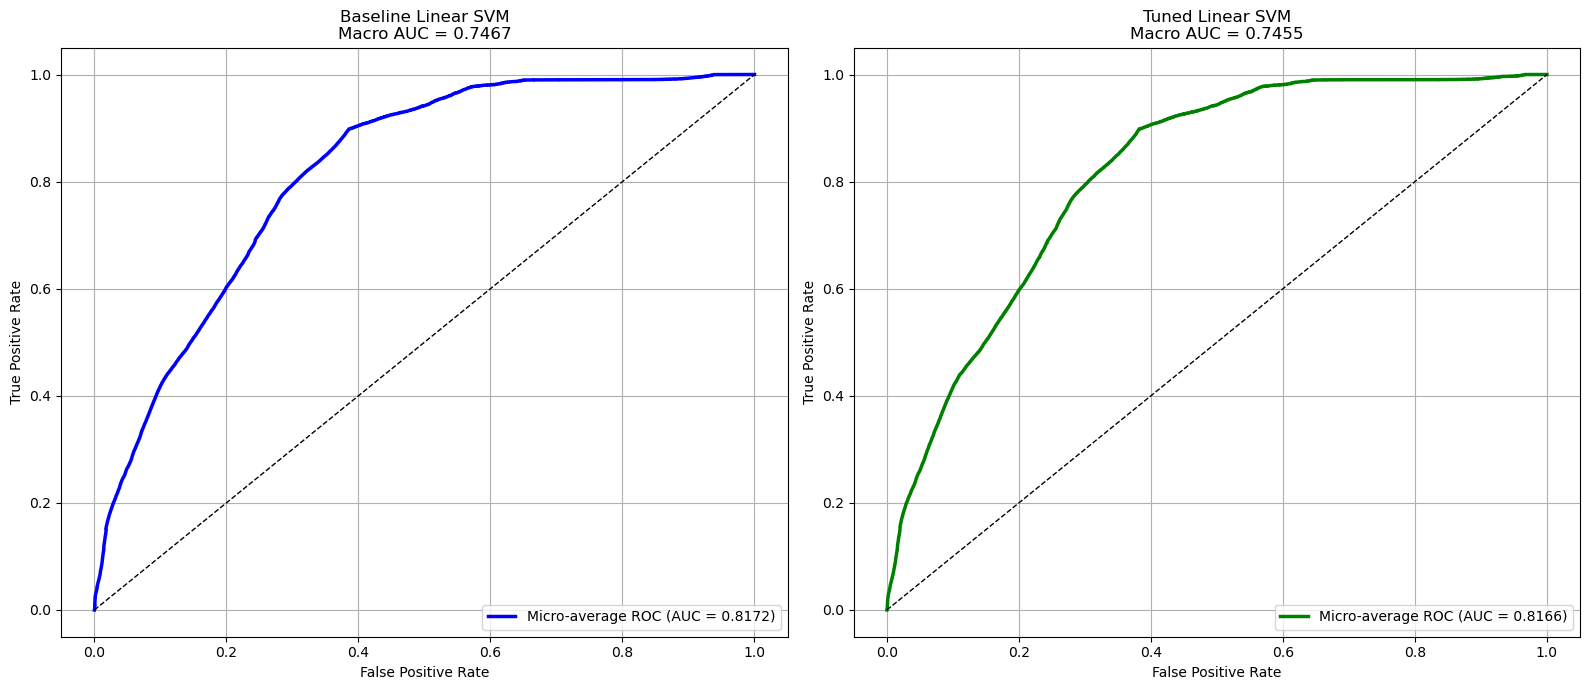

In [18]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

# Classes
classes = np.unique(y_test)

# Binarize labels
y_test_bin = label_binarize(y_test, classes=classes)

# Decision scores
baseline_scores = svm.decision_function(X_test)
tuned_scores = best_svm.decision_function(X_test)

# --------------------------------------------------
# Baseline Linear SVM
# --------------------------------------------------
fpr_base, tpr_base, _ = roc_curve(
    y_test_bin.ravel(),
    baseline_scores.ravel()
)

micro_auc_base = auc(fpr_base, tpr_base)

macro_auc_base = roc_auc_score(
    y_test_bin,
    baseline_scores,
    average='macro',
    multi_class='ovr'
)

# --------------------------------------------------
# Tuned Linear SVM
# --------------------------------------------------
fpr_tuned, tpr_tuned, _ = roc_curve(
    y_test_bin.ravel(),
    tuned_scores.ravel()
)

micro_auc_tuned = auc(fpr_tuned, tpr_tuned)

macro_auc_tuned = roc_auc_score(
    y_test_bin,
    tuned_scores,
    average='macro',
    multi_class='ovr'
)

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Baseline
axes[0].plot(
    fpr_base,
    tpr_base,
    linewidth=2.5,
    color='blue',
    label=f"Micro-average ROC (AUC = {micro_auc_base:.4f})"
)

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)

axes[0].set_title(
    f"Baseline Linear SVM\nMacro AUC = {macro_auc_base:.4f}"
)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")
axes[0].grid(True)

# Tuned
axes[1].plot(
    fpr_tuned,
    tpr_tuned,
    linewidth=2.5,
    color='green',
    label=f"Micro-average ROC (AUC = {micro_auc_tuned:.4f})"
)

axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1)

axes[1].set_title(
    f"Tuned Linear SVM\nMacro AUC = {macro_auc_tuned:.4f}"
)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")
axes[1].grid(True)

plt.tight_layout()
plt.show()